# Partial-t Visualization\nRuns TRELLIS.2 on a single image/prior pair, stopping SLAT diffusion at varying `stop_t` values, and saves individual shaded PNG frames per view.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path('~/Documents/vggt2/digitizing_reality/TRELLIS.2').expanduser()))

import os
os.environ['HF_HUB_OFFLINE'] = '1'
os.environ['SPCONV_ALGO'] = 'native'
os.environ['OPENCV_IO_ENABLE_OPENEXR'] = '1'
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

In [2]:
import cv2
import torch
import imageio
import numpy as np
from PIL import Image
import IPython.display as ipd

from trellis2.pipelines.relaxflow_pipeline import Trellis2ImageTo3DPipelineRelaxFlow
from trellis2.utils import render_utils
from trellis2.renderers import EnvMap

import trellis2_partial_patch  # applies monkey-patch

/home/ahc/miniconda3/envs/trellis2/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[SPARSE] Conv backend: flex_gemm; Attention backend: flash_attn
[ATTENTION] Using backend: flash_attn


In [3]:
envmap = EnvMap(torch.tensor(
    cv2.cvtColor(
        cv2.imread('./TRELLIS.2/assets/hdri/studio.exr', cv2.IMREAD_UNCHANGED),
        cv2.COLOR_BGR2RGB,
    ),
    dtype=torch.float32, device='cuda',
))

pipeline = Trellis2ImageTo3DPipelineRelaxFlow.from_pretrained('microsoft/TRELLIS.2-4B')
pipeline.cuda()

/home/ahc/miniconda3/envs/trellis2/lib/python3.10/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/home/ahc/miniconda3/envs/trellis2/lib/python3.10/site-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)


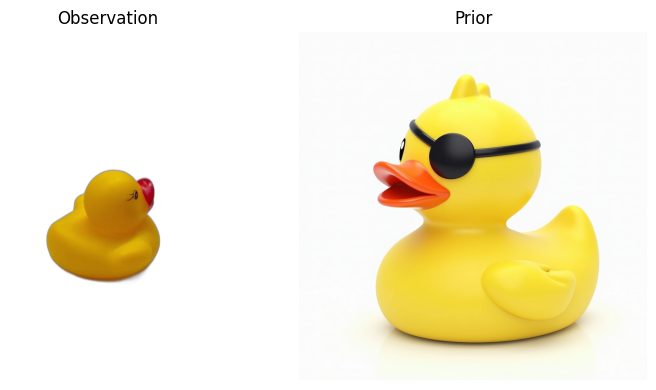

In [4]:
from matplotlib import pyplot as plt

EVAL_DATA = Path('./eval_data')

obs_image_path  = EVAL_DATA / 'DUCK/gt_obs_segmented/frame_000000.png'
prior_image_path = EVAL_DATA / 'DUCK/pred0/A yellow rubber duck with a pirate eye patch on its left, white background, centered, 3D render.png'

obs_image   = Image.open(obs_image_path)
prior_image = Image.open(prior_image_path)


# Display the inputs
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(obs_image); axes[0].set_title('Observation'); axes[0].axis('off')
axes[1].imshow(prior_image); axes[1].set_title('Prior'); axes[1].axis('off')
plt.tight_layout()
plt.show()

In [5]:
# stop_t values to sweep: 0.0 = fully denoised, 1.0 = pure noise
# FYI, trellis seems to follow a reverse-parameterization of t (w.r.t. the literature)
STOP_T_VALUES = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]

OUT_DIR = Path('./partial_t_vis_results')
OUT_DIR.mkdir(exist_ok=True)

PIPELINE_TYPE = "1024" # better to get the point across
# '1024_cascade'  # default


=== stop_t=0.0 ===


Rendering:   0%|          | 0/10 [00:00<?, ?it/s]/home/ahc/miniconda3/envs/trellis2/lib/python3.10/site-packages/utils3d/torch/nerf.py:41: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):
/home/ahc/miniconda3/envs/trellis2/lib/python3.10/site-packages/torch/nn/functional.py:5015: UserWarning: Default grid_sample and affine_grid behavior has changed to align_corners=False since 1.3.0. Please specify align_corners=True if the old behavior is desired. See the documentation of grid_sample for details.
  warnings.warn(
Rendering: 100%|██████████| 10/10 [00:04<00:00,  2.01it/s]


  saved stop_t=0.0/obs_only → 10 frames


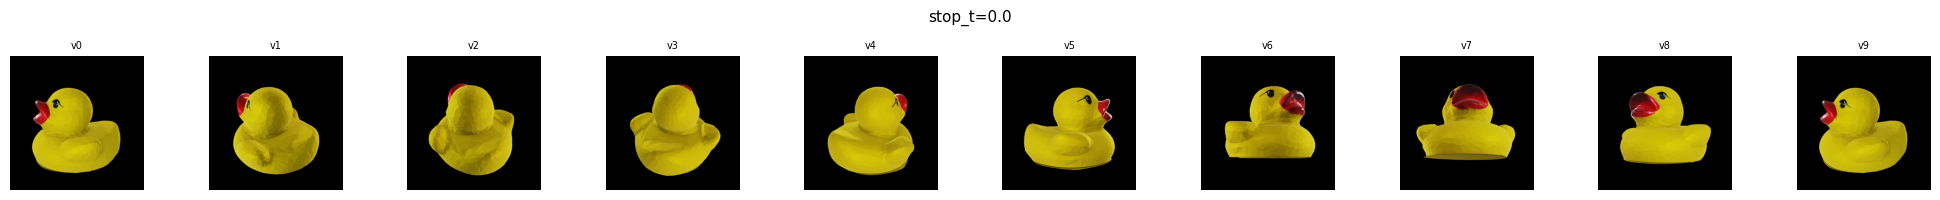


=== stop_t=0.2 ===


Rendering: 100%|██████████| 10/10 [00:03<00:00,  2.52it/s]


  saved stop_t=0.2/obs_only → 10 frames


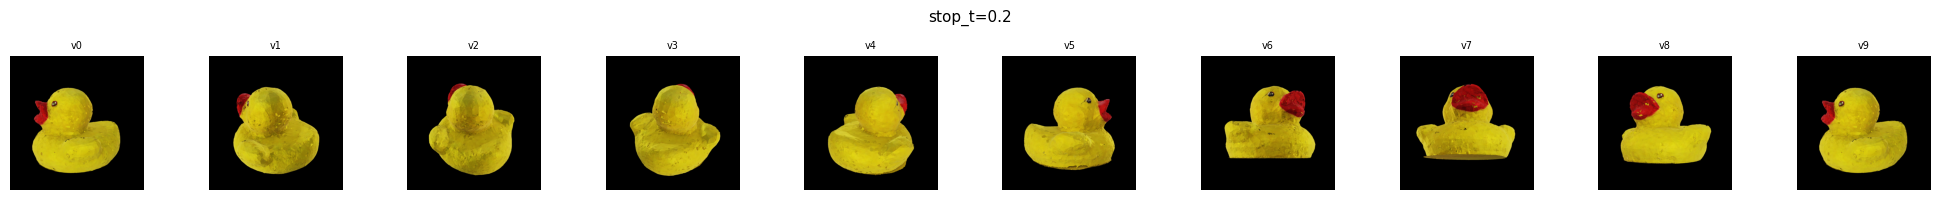


=== stop_t=0.4 ===


Rendering: 100%|██████████| 10/10 [00:03<00:00,  2.99it/s]


  saved stop_t=0.4/obs_only → 10 frames


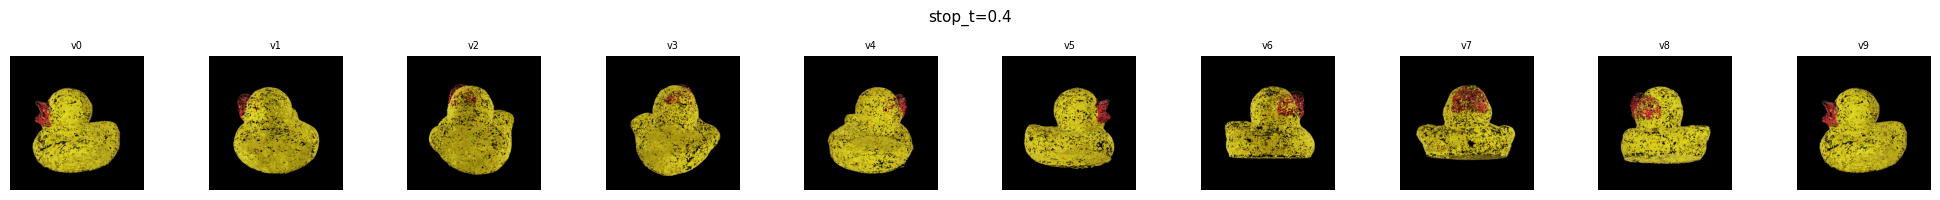


=== stop_t=0.6 ===


Rendering: 100%|██████████| 10/10 [00:04<00:00,  2.17it/s]


  saved stop_t=0.6/obs_only → 10 frames


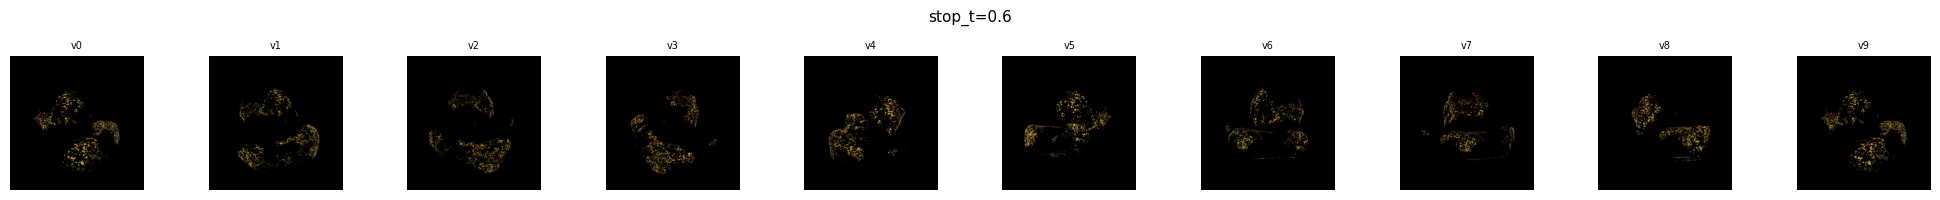


=== stop_t=0.8 ===


Rendering:   0%|          | 0/10 [00:00<?, ?it/s]/home/ahc/miniconda3/envs/trellis2/lib/python3.10/site-packages/utils3d/torch/nerf.py:41: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):
/home/ahc/miniconda3/envs/trellis2/lib/python3.10/site-packages/torch/nn/functional.py:5015: UserWarning: Default grid_sample and affine_grid behavior has changed to align_corners=False since 1.3.0. Please specify align_corners=True if the old behavior is desired. See the documentation of grid_sample for details.
  warnings.warn(
Rendering: 100%|██████████| 10/10 [00:04<00:00,  2.19it/s]


  saved stop_t=0.8/obs_only → 10 frames


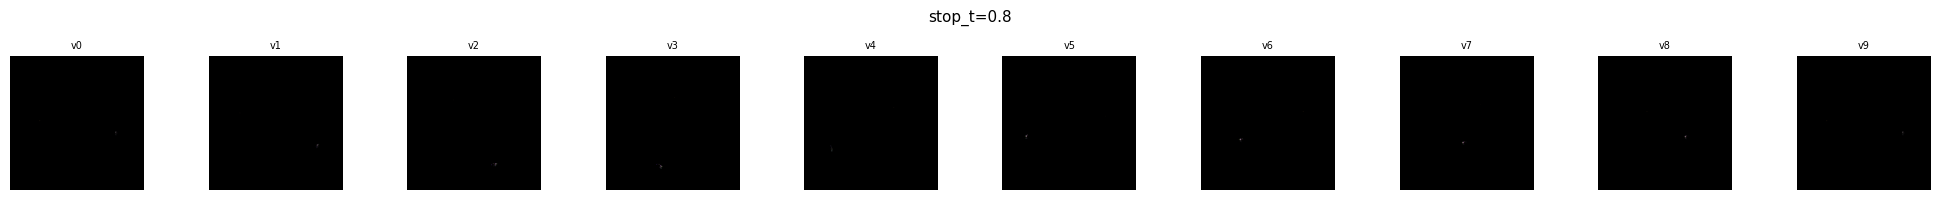


=== stop_t=1.0 ===


Sampling:   0%|          | 0/12 [00:00<?, ?it/s]


  obs_only: empty coords — black frames


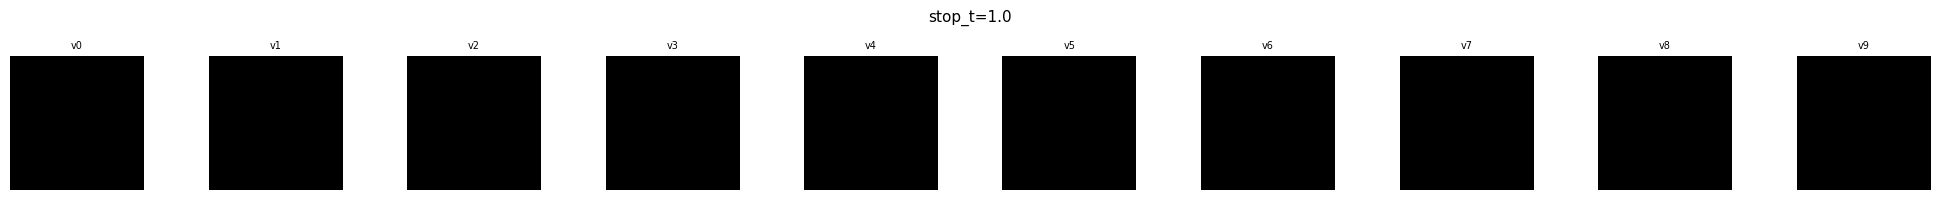

In [6]:
import matplotlib.pyplot as plt

NUM_FRAMES = 10
BRANCHES = ['obs_only']
RENDER_RES = 1024  # must match render_utils.render_video default

BLACK_FRAME = np.zeros((RENDER_RES, RENDER_RES, 3), dtype=np.uint8)

for stop_t in STOP_T_VALUES:
    print(f'\n=== stop_t={stop_t} ===')
    torch.cuda.empty_cache()

    output = pipeline.run_relaxflow_partial(
        obs_image,
        prior_images=[prior_image],
        pipeline_type=PIPELINE_TYPE,
        sparse_structure_stop_t=stop_t,
        shape_slat_stop_t=stop_t,
        tex_slat_stop_t=stop_t,
        run_branches=BRANCHES,
        prior_weight=1.0,
        prior_blur_sigma=1.0,
        seed=1,
    )

    label = f'stop_t={stop_t}'
    stop_dir = OUT_DIR / label.replace('=', '_').replace('.', 'p')
    stop_dir.mkdir(exist_ok=True)

    branch_frames = {}
    for branch in BRANCHES:
        mesh = output[branch]['mesh']
        if mesh is None:
            print(f'  {branch}: empty coords — black frames')
            branch_frames[branch] = [BLACK_FRAME] * NUM_FRAMES
            for i in range(NUM_FRAMES):
                imageio.imwrite(stop_dir / f'{branch}_view{i:02d}.png', BLACK_FRAME)
            continue
        mesh = mesh[0]
        mesh.simplify(16777216)

        raw = render_utils.render_video(mesh, envmap=envmap, num_frames=NUM_FRAMES)
        shaded = raw['shaded']

        for i, frame in enumerate(shaded):
            imageio.imwrite(stop_dir / f'{branch}_view{i:02d}.png', frame)

        branch_frames[branch] = shaded
        print(f'  saved {label}/{branch} → {NUM_FRAMES} frames')

    # Display all frames for this stop_t inline
    fig, axes = plt.subplots(len(BRANCHES), NUM_FRAMES, figsize=(2 * NUM_FRAMES, 2 * len(BRANCHES)))
    if len(BRANCHES) == 1:
        axes = [axes]
    fig.suptitle(label, fontsize=11)
    for bi, branch in enumerate(BRANCHES):
        for fi in range(NUM_FRAMES):
            ax = axes[bi][fi]
            ax.imshow(branch_frames[branch][fi])
            ax.axis('off')
            if bi == 0:
                ax.set_title(f'v{fi}', fontsize=7)
        axes[bi][0].set_ylabel(branch, fontsize=8)
    plt.tight_layout()
    plt.show()

In [ ]:
import matplotlib.pyplot as plt

NUM_FRAMES = 10
BRANCHES = ['obs_only']

for stop_t in STOP_T_VALUES:
    print(f'\n=== stop_t={stop_t} ===')
    torch.cuda.empty_cache()

    output = pipeline.run_relaxflow_partial(
        obs_image,
        prior_images=[prior_image],
        pipeline_type=PIPELINE_TYPE,
        sparse_structure_stop_t=stop_t,
        shape_slat_stop_t=stop_t,
        tex_slat_stop_t=stop_t,
        run_branches=BRANCHES,   # only sample + decode what we need
        prior_weight=1.0,
        prior_blur_sigma=1.0,
        seed=1,
    )

    label = f'stop_t={stop_t}'
    stop_dir = OUT_DIR / label.replace('=', '_').replace('.', 'p')
    stop_dir.mkdir(exist_ok=True)

    branch_frames = {}
    for branch in BRANCHES:
        mesh = output[branch]['mesh']
        if mesh is None:
            print(f'  {branch}: no mesh (empty coords), skipping')
            branch_frames[branch] = None
            continue
        mesh = mesh[0]
        mesh.simplify(16777216)

        raw = render_utils.render_video(mesh, envmap=envmap, num_frames=NUM_FRAMES)
        shaded = raw['shaded']

        for i, frame in enumerate(shaded):
            imageio.imwrite(stop_dir / f'{branch}_view{i:02d}.png', frame)

        branch_frames[branch] = shaded
        print(f'  saved {label}/{branch} → {NUM_FRAMES} frames')

    # Display all frames for this stop_t inline
    fig, axes = plt.subplots(len(BRANCHES), NUM_FRAMES, figsize=(2 * NUM_FRAMES, 2 * len(BRANCHES)))
    if len(BRANCHES) == 1:
        axes = [axes]
    fig.suptitle(label, fontsize=11)
    for bi, branch in enumerate(BRANCHES):
        frames = branch_frames[branch]
        for fi in range(NUM_FRAMES):
            ax = axes[bi][fi]
            if frames is not None:
                ax.imshow(frames[fi])
            else:
                ax.text(0.5, 0.5, 'empty', ha='center', va='center',
                        transform=ax.transAxes, fontsize=7)
            ax.axis('off')
            if bi == 0:
                ax.set_title(f'v{fi}', fontsize=7)
        axes[bi][0].set_ylabel(branch, fontsize=8)
    plt.tight_layout()
    plt.show()


=== stop_t=0.0 ===


Sampling:  58%|█████▊    | 7/12 [00:03<00:02,  1.78it/s]


KeyboardInterrupt: 

In [ ]:
import matplotlib.pyplot as plt

VIEW_IDX = 0  # which of the NUM_FRAMES views to show

n_t = len(STOP_T_VALUES)
n_b = len(BRANCHES)
fig, axes = plt.subplots(n_b, n_t, figsize=(3 * n_t, 3 * n_b))
if n_b == 1: axes = [axes]
if n_t == 1: axes = [[ax] for ax in axes]

for bi, branch in enumerate(BRANCHES):
    for ti, stop_t in enumerate(STOP_T_VALUES):
        ax = axes[bi][ti]
        frames = frames_by_stop_t[stop_t][branch]
        if frames is None:
            ax.text(0.5, 0.5, 'empty', ha='center', va='center', transform=ax.transAxes)
        else:
            ax.imshow(frames[VIEW_IDX])
        ax.axis('off')
        if bi == 0:
            ax.set_title(f'stop_t={stop_t}', fontsize=9)
        if ti == 0:
            ax.set_ylabel(branch, fontsize=9)

plt.tight_layout()
plt.show()